## Problem Context
# CKYC SFTP Log Investigation

### Business Situation:

Surepass provides SFTP-based CKYC integrations used by multiple enterprise customers.

Recetly, customers have reported:
- Failed file transfers
- Inconsistent system behaviour

This suggests potential issues in
- System Configuration
- Client interation patterns
- Operational stability

---

### Objective of Analysis :

Using request-level SFTP logs, the goal is to:

- Identify failure patterns across:
    1. Customers
    2. Operations
    3. Error_types
- Determine whether issues are:
    1. Customer-specific(configuration issues)
    2. or system-wide(platform or deployment issues)

- Detect any change points over time indicating:
    1. System regressions
    3. Behavioural shifts

- Evaluate impact and severity across customers
- Develop a plausible incident narrative supported by data
- Recommend monitoring and preventive mechanisms.

---

### Analytical Approach :

This investigation will follow a structured approach:

1. Data Understanding
2. Failure Pattern Analysis
3. Time-series & Change Point Detection.
4. Before vs After Comparision
5. Customer Impact Analysis
6. Root Cause Analysis
7. Recommendation and Monitoring Design.

## 1. Data Understanding

## 1.1 Load & Prepare Data

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# intital setup
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Data ANyst Task-_SurePass_Technology/ckyc.SFTPConnectionLog.anonymized.csv')

In [26]:
df.info() # table Description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68177 entries, 0 to 68176
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               68177 non-null  object 
 1   email             68177 non-null  object 
 2   credential_label  68177 non-null  object 
 3   operation         68177 non-null  object 
 4   success           68177 non-null  bool   
 5   error_message     42320 non-null  object 
 6   error_type        42320 non-null  object 
 7   elapsed_seconds   68177 non-null  float64
 8   created_at        68177 non-null  object 
dtypes: bool(1), float64(1), object(7)
memory usage: 4.2+ MB


In [27]:
# Converting str to timestamp
df['created_at'] = pd.to_datetime(df['created_at'])

## 1.2 Dataset Overview

In [28]:
df.shape

(68177, 9)

- Dataset contains 68,177 request-level logs
- Each row represents a single SFTP operation attempt

### 1.3 Schema Understanding

In [29]:
df.dtypes

,0
_id,object
email,object
credential_label,object
operation,object
success,bool
error_message,object
error_type,object
elapsed_seconds,float64
created_at,"datetime64[ns, UTC]"


- `_id` --> Likely event id  or transaction id but we won't be using it much in this analysis
- `email` --> customer identifier  
- `operation` --type of SFTP action  
- `success` -->request outcome  
- `error_type` -->failure classification  
- `elapsed_seconds` -->request latency  
- `created_at` -->timestamp of request  

This is event-level operational log data.

### 1.4 Missing Values

In [30]:
df.isnull().sum()

,0
_id,0
email,0
credential_label,0
operation,0
success,0
error_message,25857
error_type,25857
elapsed_seconds,0
created_at,0


- Missing values present only in `error_type` and `error_message`
- These correspond to successful requests
- No major data quality issues observed

### 1.5 System Complexity( Cardinality)

In [31]:
print(f"Distinct emails :{df['email'].nunique()}")
print(f"Distinct operations : {df['operation'].nunique()}")
print(f"Disctinct error types : {df['error_type'].nunique()}")

Distinct emails :5
Distinct operations : 11
Disctinct error types : 7


### 1.6 Key Observations

- Only 5 customers -->high sensitivity to per-customer issues
- 11 operations -->multiple interaction patterns with the system
- 7 error types -->structured and repeatable failure modes

**Implication:**
- If failures are spread across customers -->likely system issue
- If concentrated -->likely configuration/client issue

## 2. Failure Pattern Analysis

## 2.1 Baseline System Health

In [32]:
failure_rate = 1 - df['success'].mean()
failure_rate * 100

np.float64(62.07371987620458)

In [33]:
df['created_at'].min(), df['created_at'].max()

(Timestamp('2026-02-12 12:43:57.384000+0000', tz='UTC'),
 Timestamp('2026-03-13 06:20:18.784000+0000', tz='UTC'))

- Failure rate = 62.07%
- Data spans from 2026-02-12 to 2026-03-13

- System appears **critically unstable**, as more than half of all requests are failing.

- A failure rate above 20% typically indicates systemic issues; at 62%, this strongly suggests a major incident rather than isolated configuration errors.

- Given the limited number of customers (5), such a high failure rate likely impacts multiple customers simultaneously, pointing toward a system-wide issue rather than isolated client-specific problems.

## 2.2 Failure Breakdown by Customer

In [34]:
customer_analysis = df.groupby('email').agg(
    total_requests = ('success', 'count'),
    failures = ('success', lambda x : (~x).sum())
)

# We got total requests and failed requests.
# Calculate failure rate by each customer

customer_analysis['failure_rate'] = ((customer_analysis['failures'] / customer_analysis['total_requests']) * 100).round(2)

# Sorting customers by highest failure rate

customer_analysis = customer_analysis.sort_values(by = 'failure_rate', ascending = False)

customer_analysis

,total_requests,failures,failure_rate
email,,,
user004@example.com,6,6,100.00
user005@example.com,18423,16398,89.01
user003@example.com,48892,25900,52.97
user002@example.com,118,4,3.39
user001@example.com,738,12,1.63



- Failure rates vary significantly across customers, indicating non-uniform system behavior.

- user005 (~89%) and user003 (~53%) show extremely high failure rates at large request volumes.
- user001 and user002 show minimal failure rates (<5%), indicating stable interactions.

- user004 shows 100% failure, but with only 6 requests — this is not statistically significant.

**Interpretation:**
- Failures are not uniformly distributed -->not a complete system-wide outage.
- However, multiple high-volume customers are heavily impacted -->suggests a shared issue affecting specific segments.

- This points toward a **partial system failure or configuration/operation-specific issue**, rather than isolated customer errors.

## 2.3 Failure breakdown by operation

In [35]:
operation_analysis = df.groupby('operation').agg(
    total_requests = ('success', 'count'),
    failures = ('success', lambda x :(~x).sum())
)

# finding failure rate
operation_analysis['failure_rate'] = ((operation_analysis['failures'] / operation_analysis['total_requests'] * 100).round(2))

# sorting by failure_rate

operation_analysis = operation_analysis.sort_values(by = 'failure_rate' , ascending = False)

operation_analysis

,total_requests,failures,failure_rate
operation,,,
upload,5576,5108,91.61
bulk_download,54280,35310,65.05
probe,77,47,61.04
download,4985,1834,36.79
list_responses,10,1,10.00
bulk_upload_session,431,3,0.70
bulk_download_session,2032,13,0.64
download_session,767,4,0.52
list_input,7,0,0.00



- Failure rates vary significantly across operations, indicating non-uniform system behavior.

- `upload` (~91.6%) and `bulk_download` (~65.0%) exhibit extremely high failure rates.
- `bulk_download` also has very high request volume (~54K), making it the primary contributor to overall failures.
- `download` shows moderate failure (~36.8%), suggesting partial degradation.

- Session-related operations (`*_session`) show near-zero failure rates, indicating that core connectivity and session handling are functioning correctly.

**Interpretation:**
- Failures are operation-specific rather than system-wide.
- The system is partially functional, with critical failures concentrated in specific high-impact operations.
- This suggests issues related to:
  - permissions
  - file handling logic
  - or operation-specific configuration

- Combined with customer-level analysis, this indicates that affected customers are likely those heavily using failing operations such as `upload` and `bulk_download`.

## 2.4 Failure by Error_type

In [36]:
error_analysis = df[df['success'] == False]['error_type'].value_counts()

error_analysis

,count
error_type,
PermissionDenied,26153
TimeoutError,8667
ConnectionLost,7214
ChannelOpenError,271
FileNotFoundError,10
OSError,3
SFTPNoSuchFile,2


- The majority of failures are driven by `PermissionDenied` errors (~26K occurrences), making it the dominant failure mode.

- Secondary errors include `TimeoutError` (~8.6K) and `ConnectionLost` (~7.2K), which may be downstream effects rather than primary causes.

- Other error types are negligible and do not contribute significantly to system instability.

**Interpretation:**
- The dominance of `PermissionDenied` strongly indicates a configuration or access control issue rather than random system instability.

- Combined with operation-level analysis:
  - High failure rates in `upload` and `bulk_download`
  - Suggest that these operations require permissions that are either misconfigured or missing

- Secondary errors (timeouts, connection loss) are likely cascading effects due to repeated failures or retries.

**Conclusion:**
- The primary driver of failures appears to be **permission-related issues affecting specific operations and customers**, rather than a full system outage.

## 3. Time-Series & Change Point Detection

In [37]:
time_analysis = df.groupby(df['created_at'].dt.date).agg(
    total_requests = ('success','count'),
    failures = ('success', lambda x : (~x).sum())
)

# calculation of failure rate by time_analysis

time_analysis['failure_rate'] = ((time_analysis['failures'] / time_analysis['total_requests']) * 100).round(2)

time_analysis

,total_requests,failures,failure_rate
created_at,,,
2026-02-12,2932,456,15.55
2026-02-13,6371,2546,39.96
2026-02-14,6198,6198,100.00
2026-02-15,6201,6201,100.00
2026-02-16,6523,6523,100.00
2026-02-17,7426,6765,91.10
2026-02-18,5956,5956,100.00
2026-02-19,5532,5532,100.00
2026-02-20,6456,1851,28.67


- The system shows a clear multi-phase behavior over time.

**Pre-Incident Phase (Feb 12–13):**
- Failure rate ranges between ~15% and ~40%
- Indicates some instability but not a full outage

**Incident Phase (Feb 14–19):**
- Failure rates spike to **~100% for multiple consecutive days**
- Represents a complete system failure affecting nearly all requests

**Recovery Phase (Feb 20):**
- Failure rate drops to ~28%
- Indicates partial restoration of functionality

**Stabilization Phase (Feb 21 onward):**
- Failure rate falls below 5% and stabilizes near 0%
- System returns to normal operation

**Interpretation:**
- A major incident began on **Feb 14**, likely triggered by a system or configuration change
- The system remained critically broken for ~5–6 days
- A fix or rollback was implemented around **Feb 20**, restoring stability

- This pattern strongly suggests:
  - a deployment or configuration change introduced failure
  - followed by corrective action that resolved the issue

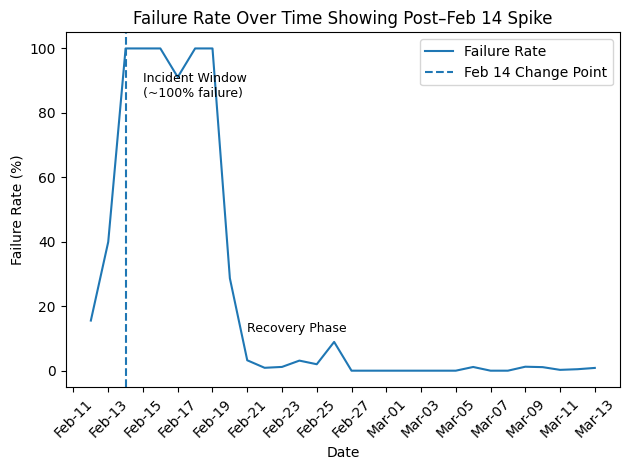

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Aggregate daily failure rate
time_analysis = df.groupby(df['created_at'].dt.date)['success'].agg(
    total='count',
    failures=lambda x: (~x).sum()
)

time_analysis['failure_rate'] = (time_analysis['failures'] / time_analysis['total']) * 100

# Plot
plt.figure()
plt.plot(time_analysis.index, time_analysis['failure_rate'], label='Failure Rate')

# Change point
change_date = pd.to_datetime('2026-02-14').date()
plt.axvline(change_date, linestyle='--', label='Feb 14 Change Point')

# Axis formatting
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)

# Annotations
plt.text(pd.to_datetime('2026-02-15').date(), 85, 'Incident Window\n(~100% failure)', fontsize=9)
plt.text(pd.to_datetime('2026-02-21').date(), 12, 'Recovery Phase', fontsize=9)

# Labels
plt.title('Failure Rate Over Time Showing Post–Feb 14 Spike')
plt.xlabel('Date')
plt.ylabel('Failure Rate (%)')
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

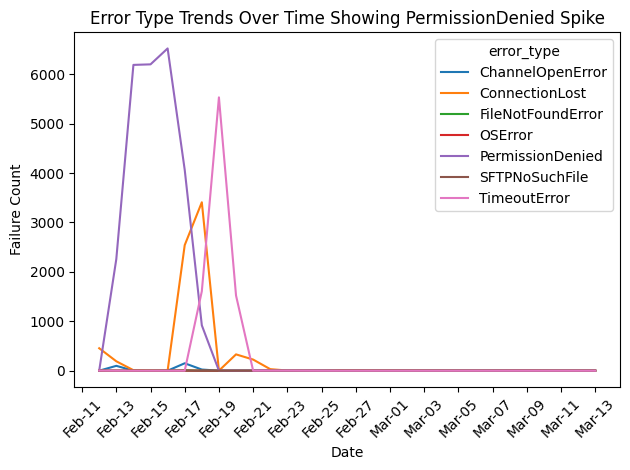

In [49]:
# Create date column
df['date'] = df['created_at'].dt.date

# Filter failures only
failures = df[~df['success']]

# Group by date and error type
error_trend = failures.groupby(['date', 'error_type']).size().unstack(fill_value=0)

# Plot
plt.figure()
error_trend.plot()

# Titles and labels
plt.title('Error Type Trends Over Time Showing PermissionDenied Spike')
plt.xlabel('Date')
plt.ylabel('Failure Count')

# Improve x-axis
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Before vs After Comparision

In [39]:
change_date = '2026-02-14'

before = df[df['created_at'] < change_date]
after = df[df['created_at'] >= change_date]


# comparing system behaviour

def summarize(data):
    return{
        "requests" : len(data),
        "failure_rate" : round((1 - data['success'].mean())* 100,2),
        "avg_latency" : round(data['elapsed_seconds'].mean(),2)
    }

print("Before : ",summarize(before))
print("After : ", summarize(after))

Before :  {'requests': 9303, 'failure_rate': np.float64(32.27), 'avg_latency': np.float64(6.99)}
After :  {'requests': 58874, 'failure_rate': np.float64(66.78), 'avg_latency': np.float64(19.27)}


**Before Feb 14:**
- ~9.3K requests
- Failure rate ~32%
- Average latency ~7 seconds

**After Feb 14:**
- ~58.8K requests
- Failure rate ~66.8%
- Average latency ~19.3 seconds

**Key Observations:**

- Failure rate more than doubled, indicating a major degradation in system reliability.
- Average latency nearly tripled, suggesting increased system strain, retries, or blocked operations.
- Request volume increased significantly, likely driven by repeated retries due to failures rather than genuine usage growth.

**Interpretation:**

- The sharp increase in both failure rate and latency confirms a systemic issue introduced around Feb 14.
- The rise in request volume, combined with high failure rates, suggests that clients may have retried failed operations, further stressing the system.

- This supports the hypothesis that:
  - a configuration or permission-related issue affected key operations
  - leading to cascading failures, retries, and degraded performance

## 5. Customer Impact Analysis

In [40]:
customer_impact = df.groupby('email').agg(
    total_requests=('success','count'),
    failure_rate=('success', lambda x: (~x).mean() * 100)
)

customer_impact['impact_score'] = (
    customer_impact['total_requests'] * customer_impact['failure_rate']/100
)

customer_impact = customer_impact.sort_values(by='impact_score', ascending=False)

customer_impact.round(2)

,total_requests,failure_rate,impact_score
email,,,
user003@example.com,48892,52.97,25900.0
user005@example.com,18423,89.01,16398.0
user001@example.com,738,1.63,12.0
user004@example.com,6,100.00,6.0
user002@example.com,118,3.39,4.0


- user003 is the most impacted customer with ~25,900 failed requests, driven by a combination of high request volume (~48,892) and a substantial failure rate (~52.97%).

- user005 shows the highest failure rate (~89.01%), but lower volume (~18,423), resulting in ~16,398 failed requests and lower overall impact compared to user003.

- user001 and user002 show minimal impact, with very low failure rates and negligible failed requests.

- user004 shows a 100% failure rate, but with only 6 requests, making it statistically insignificant.

**Interpretation:**
- Impact is best measured using **failed request volume (impact_score)**, which combines both failure rate and request volume.
- High failure rates alone do not determine impact — volume is a critical factor.
- user003 represents the most significant business impact due to the large number of failed operations.

## 6. Root cause Analysis

### 6.1 Incident Narrative

- Between **Feb 14–19**, the system experienced a critical failure, with failure rates reaching ~100%.
- The issue primarily impacted high-volume customers (user003, user005).
- System performance degraded significantly (higher latency and request volume).
- Recovery began around **Feb 20**, indicating a fix or rollback.

---

### 6.2 Root Cause Hypothesis

- The failure was likely caused by a **permission or configuration change** affecting key operations (`upload`, `bulk_download`).
- This led to access failures and repeated retries, increasing system load.

---

### 6.3 Supporting Evidence

- Sharp failure spike during Feb 14–19
- Dominance of `PermissionDenied` errors
- High failure rates in `upload` and `bulk_download`
- Impact concentrated in specific high-volume customers
- Increased latency and request volume during incident

---

### 6.4 Uncertainty & Limitations

- Root cause cannot be confirmed without deployment or access logs
- Retry behavior is inferred, not directly observed

---

## Client Behavior Insights

- Request volume increased significantly during the incident, likely due to retries.
- High failure + high latency suggests repeated attempts by clients, amplifying system load.



## 7. Recommendations & Monitoring

### Monitoring

- Alert if failure rate exceeds threshold (e.g., >10%)
- Track error-type spikes (especially PermissionDenied)
- Monitor failure rates per operation
- Track latency anomalies

---

### Prevention

- Validate permissions before deployment
- Use canary releases for configuration changes
- Add automated access checks for critical operations
- Implement controlled retry mechanisms